In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)


# LOAD DATA

proj_path = os.getcwd()
print("Project Path = ",proj_path)

file_path = proj_path + "\\Hotel Reservations.csv"
print("File Path = ",file_path)

df = pd.read_csv(file_path)
print("Dataset shape:", df.shape)
print(df.head())
print("\nMissing values per column:\n", df.isnull().sum())
 
# Drop identifier column - not predictive
df = df.drop(columns=["Booking_ID"])

print("____________________________________________________________________________")
print(df.head())
print("____________________________________________________________________________")
print("The shape of the dataset:\n",df.shape)
print("____________________________________________________________________________")
print("The info of the dataset:\n",df.info)
print("____________________________________________________________________________")
print("Data type:\n",df.dtypes)
print("____________________________________________________________________________")
print("Calculating missing value:\n", df.isnull().sum().sum())
print("____________________________________________________________________________")
print("The Target Distribution:\n",df['booking_status'].value_counts())
print("____________________________________________________________________________")
print("The description of  the dataset:\n",df.describe(include='all').T)
print("____________________________________________________________________________")

print("Booking Status Distribution:")
print(df["booking_status"].value_counts())

plt.figure(figsize=(6,4))

ax = sns.countplot(x="booking_status", data=df)

plt.title("Booking Status Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")

# Add count labels on top of each bar
for container in ax.containers:
    ax.bar_label(container)
plt.grid()
plt.tight_layout()
plt.show()



Target distribution:
 booking_status
0    0.672364
1    0.327636
Name: proportion, dtype: float64
____________________________________________________________________________

Feature matrix shape after encoding: (36275, 27)
____________________________________________________________________________

Train size: 29020, Test size: 7255
____________________________________________________________________________


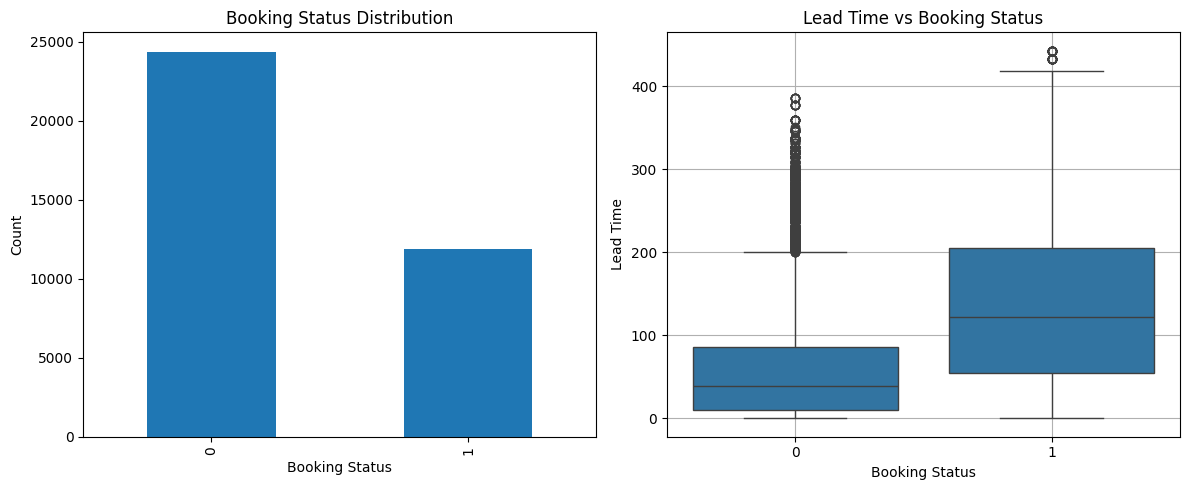

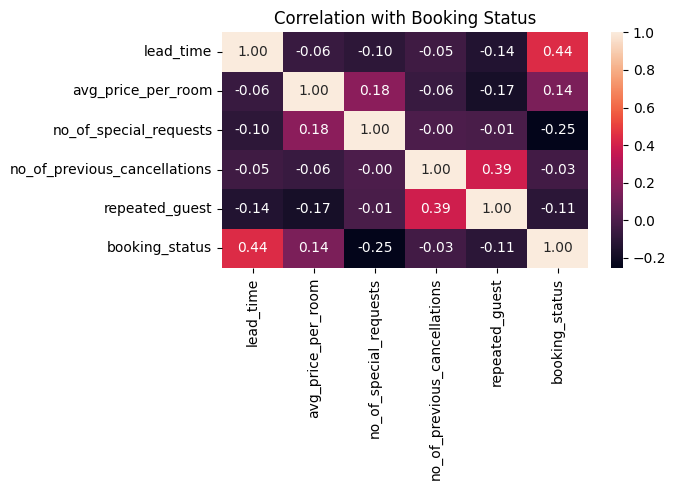

In [2]:

# TARGET ENCODING

# booking_status: Canceled: 1, Not Canceled: 0
df["booking_status"] = df["booking_status"].map({"Canceled": 1, "Not_Canceled": 0})
print("\nTarget distribution:\n", df["booking_status"].value_counts(normalize=True))
print("____________________________________________________________________________")

# EXPLORATORY DATA ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Booking Status Distribution
df["booking_status"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Booking Status Distribution")
axes[0].set_xlabel("Booking Status")
axes[0].set_ylabel("Count")
categorical_cols = ["type_of_meal_plan", "room_type_reserved", "market_segment_type"]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
 
X = df_encoded.drop(columns=["booking_status"])
y = df_encoded["booking_status"]
 
print("\nFeature matrix shape after encoding:", X.shape)

print("____________________________________________________________________________") 

# TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print("____________________________________________________________________________")
 
# SCALING 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Lead Time vs Booking Status
sns.boxplot(data=df, x="booking_status", y="lead_time", ax=axes[1])
axes[1].set_title("Lead Time vs Booking Status")
axes[1].set_xlabel("Booking Status")
axes[1].set_ylabel("Lead Time")
plt.grid()
plt.tight_layout()
plt.show()

# Correlation Heatmap
corr_cols = [
    "lead_time",
    "avg_price_per_room",
    "no_of_special_requests",
    "no_of_previous_cancellations",
    "repeated_guest",
    "booking_status"
]

plt.figure(figsize=(7, 5))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    fmt=".2f"
)
plt.title("Correlation with Booking Status")
plt.tight_layout()
plt.show()

In [3]:
#ENCODING
categorical_cols = ["type_of_meal_plan", "room_type_reserved", "market_segment_type"]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
 
X = df_encoded.drop(columns=["booking_status"])
y = df_encoded["booking_status"]
 
print("\nFeature matrix shape after encoding:", X.shape)

print("____________________________________________________________________________") 

# TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print("____________________________________________________________________________")
 
# SCALING 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Feature matrix shape after encoding: (36275, 27)
____________________________________________________________________________

Train size: 29020, Test size: 7255
____________________________________________________________________________


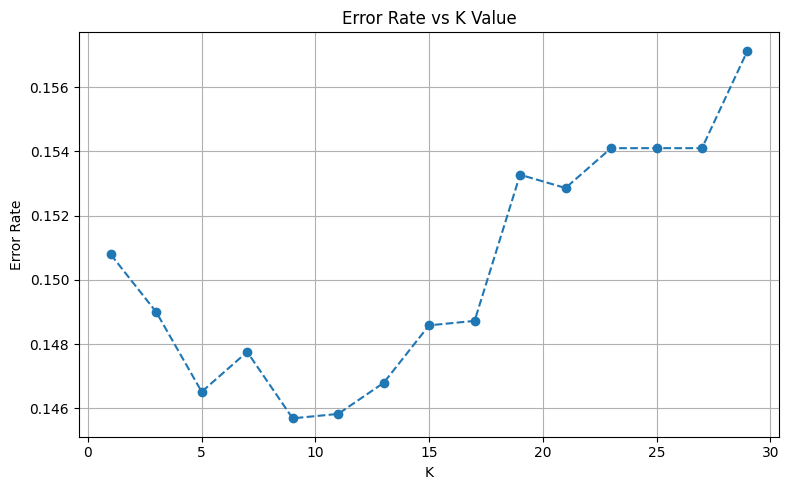


Best K from Error Rate Graph: 9

Final KNN Model:
KNeighborsClassifier(metric='euclidean', n_neighbors=9)
____________________________________________________________________________


In [5]:

#FINDING K

error_rates = []
k_range = range(1, 31, 2)
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    error_rates.append(np.mean(pred != y_test))
 
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), error_rates, marker="o", linestyle="--")
plt.title("Error Rate vs K Value")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.tight_layout()
plt.grid()
plt.show()
# Best K from Error Rate Graph
best_k = list(k_range)[int(np.argmin(error_rates))]
print(f"\nBest K from Error Rate Graph: {best_k}")

# Train Final KNN Model
best_knn = KNeighborsClassifier(
    n_neighbors=best_k,
    weights="uniform",
    metric="euclidean"
)

best_knn.fit(X_train_scaled, y_train)

print("\nFinal KNN Model:")
print(best_knn)

print("____________________________________________________________________________") 


=== Final Model Performance (Test Set) ===
Accuracy : 0.8543
Precision: 0.7997
Recall   : 0.7408
F1 Score : 0.7692
ROC-AUC  : 0.9124

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.89      4878
           1       0.80      0.74      0.77      2377

    accuracy                           0.85      7255
   macro avg       0.84      0.83      0.83      7255
weighted avg       0.85      0.85      0.85      7255



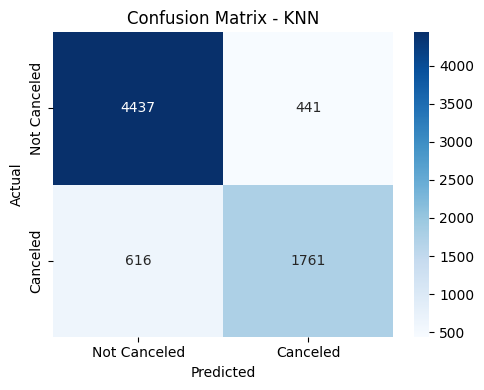

<function matplotlib.pyplot.show(close=None, block=None)>

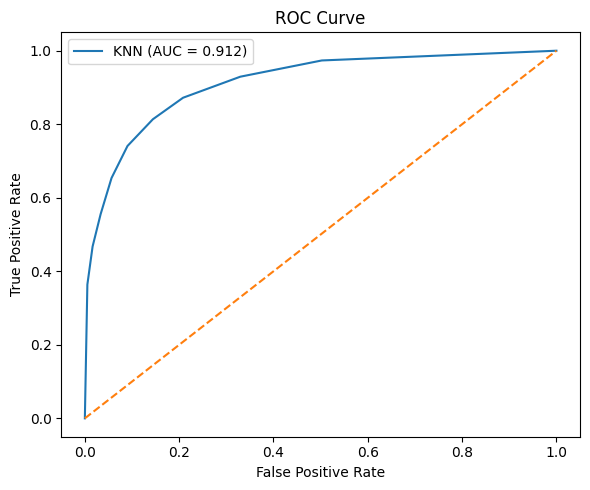

In [7]:
#MODEL EVALUATION ON TEST SET
y_pred = best_knn.predict(X_test_scaled)
y_proba = best_knn.predict_proba(X_test_scaled)[:, 1]
 
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
 
print("\n=== Final Model Performance (Test Set) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
 
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Not Canceled", "Canceled"],
    yticklabels=["Not Canceled", "Canceled"]
)
plt.title("Confusion Matrix - KNN")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()
 
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"KNN (AUC = {auc:.3f})", )
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show